# Credit Risk Dataset — Cleaning & Visual Analysis

Pipeline: Pandas (clean) -> Visualization (matplotlib/seaborn) -> further analysis in SQL / Power BI

This notebook cleans the raw credit risk data and builds plots at two stages:
first on the raw data (to see what needs fixing), and then after cleaning
(to understand who is defaulting and why).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load Data

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns)
df.info()

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


## 2. Data Quality Checks

In [3]:
print("\nMissing values per column:")
print(df.isnull().sum())
print("Total missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
print(df.describe())


Missing values per column:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
Total missing values: 4011

Duplicate rows: 165

Summary statistics:
         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04          

### 2.1 Missing Values Heatmap (Raw Data, Before Cleaning)
Each line shows a missing cell. Only `person_emp_length` and `loan_int_rate` have gaps.

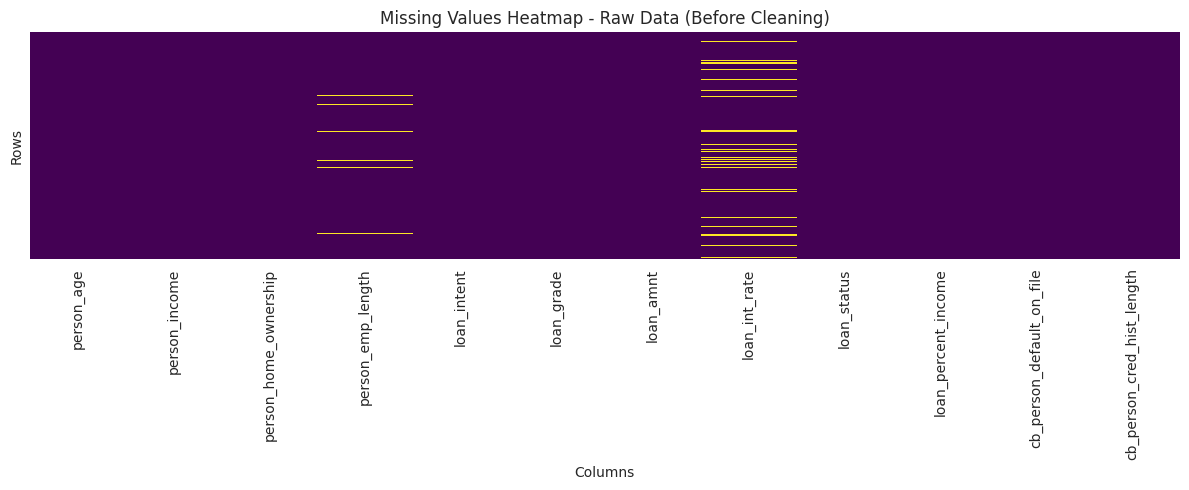

In [4]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap - Raw Data (Before Cleaning)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

### 2.2 Outlier Check — Age & Employment Length (Before Removal)
The raw data has clearly impossible values (age around 144, employment length around 123 years).

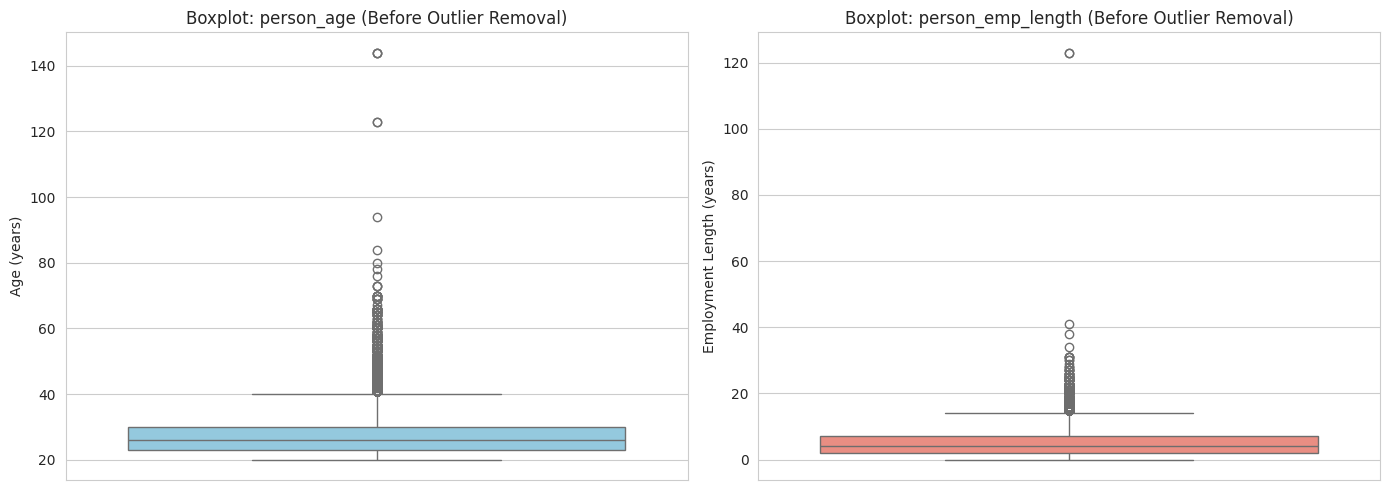

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['person_age'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot: person_age (Before Outlier Removal)')
axes[0].set_ylabel('Age (years)')

sns.boxplot(y=df['person_emp_length'], color='salmon', ax=axes[1])
axes[1].set_title('Boxplot: person_emp_length (Before Outlier Removal)')
axes[1].set_ylabel('Employment Length (years)')

plt.tight_layout()
plt.show()

## 3. Remove Duplicates

In [6]:
df = df.drop_duplicates()
df = df.copy()  # avoids SettingWithCopyWarning on later assignments

print("\nDuplicate rows after removal:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)


Duplicate rows after removal: 0
Shape after removing duplicates: (32416, 12)


## 4. Handle Missing Values
Median fill is used since it is safe against outliers.

In [7]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

print("\nMissing values after fill:")
print(df.isnull().sum())


Missing values after fill:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


## 5. Handle Outliers
`person_age > 80` and `person_emp_length > 40` are unrealistic values (e.g. the raw data had age = 144 and emp_length = 123, which are not possible).

In [8]:
age_outliers = df[df['person_age'] > 80]
emp_outliers = df[df['person_emp_length'] > 40]

print(f"\nAge outliers count: {age_outliers.shape[0]}")
print(f"Emp length outliers count: {emp_outliers.shape[0]}")

df = df[(df['person_age'] <= 80) & (df['person_emp_length'] <= 40)]
print("Shape after removing outliers:", df.shape)


Age outliers count: 7
Emp length outliers count: 3
Shape after removing outliers: (32406, 12)


## 6. Derived Column — Age Group

In [9]:
bins = [20, 25, 35, 45, 60, 80]
labels = ['20-25', '26-35', '36-45', '46-60', '60+']
df['age_group'] = pd.cut(df['person_age'], bins=bins, labels=labels, include_lowest=True)

print("\nAge group distribution:")
print(df['age_group'].value_counts().sort_index())


Age group distribution:
age_group
20-25    15243
26-35    13711
36-45     2809
46-60      581
60+         62
Name: count, dtype: int64


## 7. Derived Column — Loan Amount Group

In [10]:
bins_loan = [0, 5000, 10000, 20000, 35000]
labels_loan = ['Low', 'Medium', 'High', 'Very High']
df['loan_amount_group'] = pd.cut(df['loan_amnt'], bins=bins_loan, labels=labels_loan, include_lowest=True)

print("\nLoan amount group distribution:")
print(df['loan_amount_group'].value_counts().sort_index())


Loan amount group distribution:
loan_amount_group
Low           9427
Medium       11980
High          8872
Very High     2127
Name: count, dtype: int64


## 8. Replace Y/N With Yes/No
Makes the `cb_person_default_on_file` column easier to read in plots and reports.

In [11]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].replace({'Y': 'Yes', 'N': 'No'})

## 9. Quick Sanity Checks

In [12]:
print("\nOverall default rate (%):")
print(df['loan_status'].value_counts(normalize=True).mul(100).round(2))

print("\nAge range:", df['person_age'].min(), "-", df['person_age'].max())
print("Average income:", round(df['person_income'].mean(), 2))
print("Average loan amount:", round(df['loan_amnt'].mean(), 2))


Overall default rate (%):
loan_status
0    78.13
1    21.87
Name: proportion, dtype: float64

Age range: 20 - 80
Average income: 65895.23
Average loan amount: 9592.77


## 10. Final Validation Before Export

In [13]:
assert df.isnull().sum().sum() == 0, "Unexpected nulls found before export"
assert df.duplicated().sum() == 0, "Unexpected duplicates found before export"

print("\nFinal shape:", df.shape)
print("Final columns:", df.columns.tolist())


Final shape: (32406, 14)
Final columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'age_group', 'loan_amount_group']


---
## 11. Visual Analysis (On Cleaned Data)

`loan_status` is the target column here (`1` = defaulted, `0` = did not default).
The plots below look at who is defaulting and which factors seem to matter.

### 11.1 Loan Status Distribution
How balanced is the target column?

/tmp/ipykernel_88/752669606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_status', data=df, palette=['#4C72B0', '#DD8452'])
/tmp/ipykernel_88/752669606.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Default (0)', 'Default (1)'])


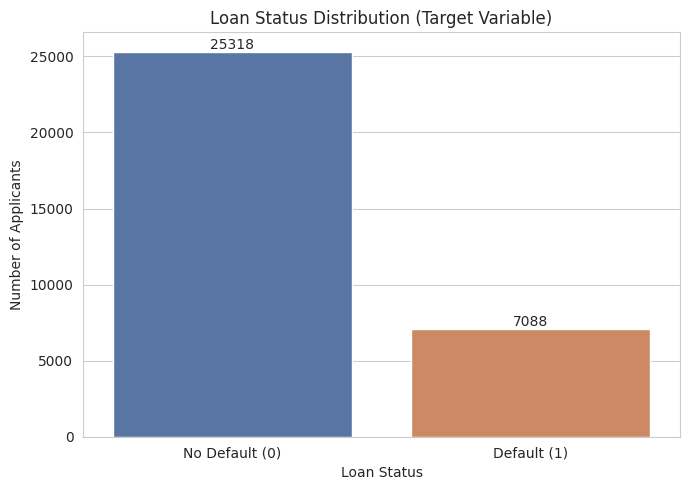

In [14]:
status_counts = df['loan_status'].value_counts()

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='loan_status', data=df, palette=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No Default (0)', 'Default (1)'])
ax.set_title('Loan Status Distribution (Target Variable)')
ax.set_xlabel('Loan Status')
ax.set_ylabel('Number of Applicants')

for i, count in enumerate(status_counts.sort_index()):
    ax.text(i, count + 200, str(count), ha='center')

plt.tight_layout()
plt.show()

### 11.2 Numeric Column Distributions
Age, income, loan amount, and interest rate — all in one view.

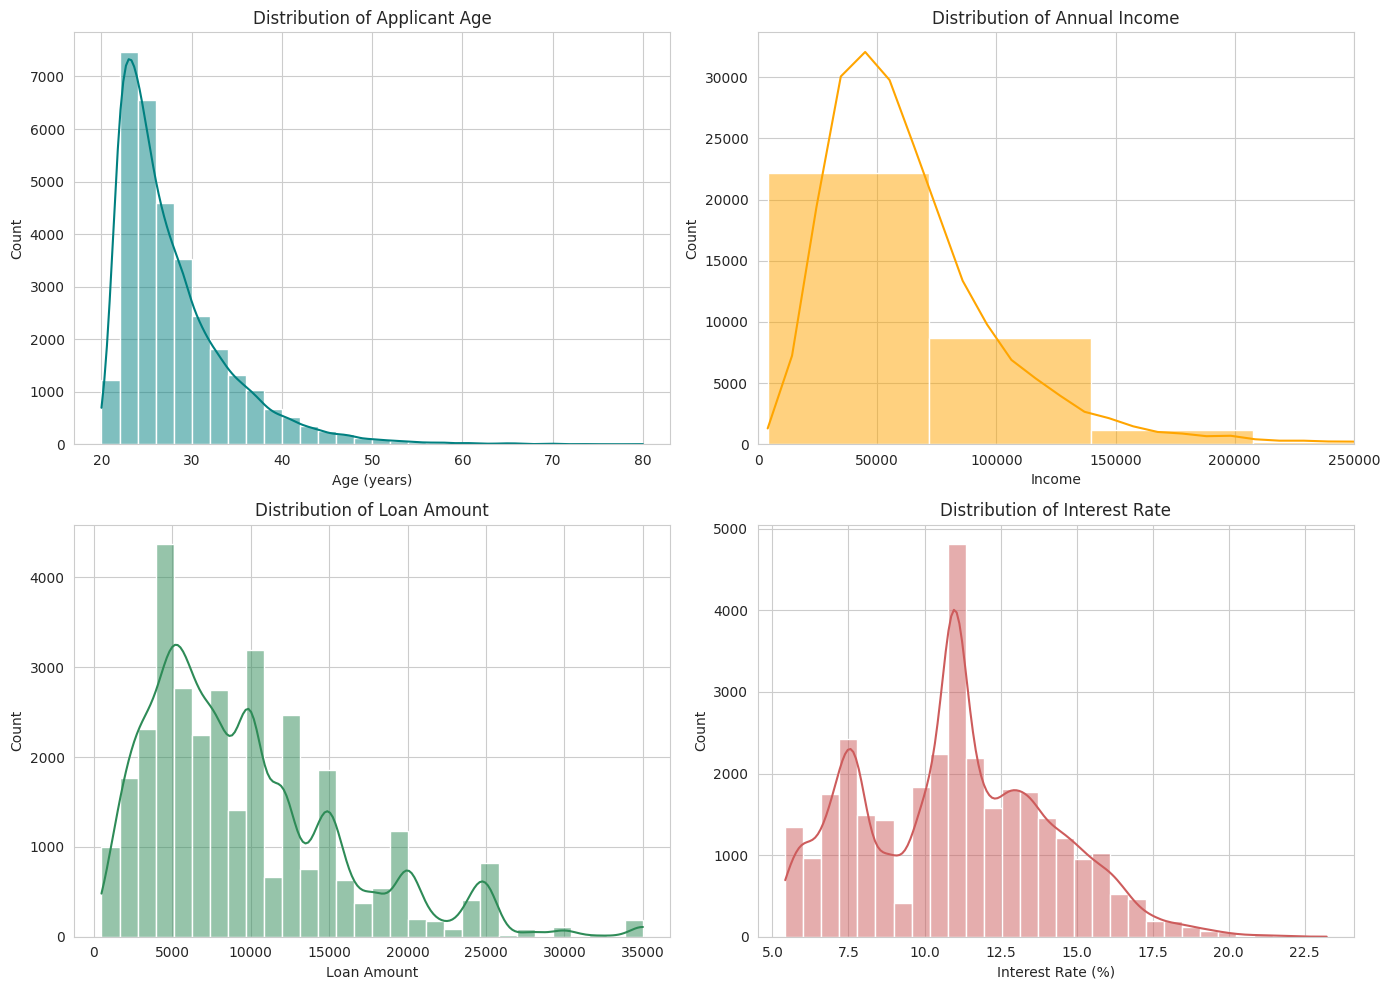

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['person_age'], bins=30, kde=True, color='teal', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Applicant Age')
axes[0, 0].set_xlabel('Age (years)')

sns.histplot(df['person_income'], bins=30, kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Annual Income')
axes[0, 1].set_xlabel('Income')
axes[0, 1].set_xlim(0, 250000)

sns.histplot(df['loan_amnt'], bins=30, kde=True, color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Loan Amount')
axes[1, 0].set_xlabel('Loan Amount')

sns.histplot(df['loan_int_rate'], bins=30, kde=True, color='indianred', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Interest Rate')
axes[1, 1].set_xlabel('Interest Rate (%)')

plt.tight_layout()
plt.show()

### 11.3 Loan Intent Breakdown
What are people borrowing for?

/tmp/ipykernel_88/3150497296.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='loan_intent', data=df, order=order, palette='Blues_r')


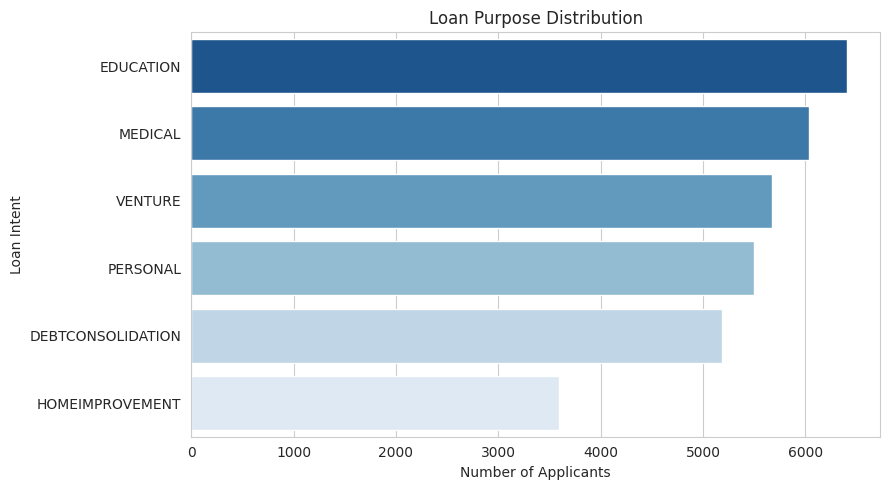

In [16]:
plt.figure(figsize=(9, 5))
order = df['loan_intent'].value_counts().index
ax = sns.countplot(y='loan_intent', data=df, order=order, palette='Blues_r')
ax.set_title('Loan Purpose Distribution')
ax.set_xlabel('Number of Applicants')
ax.set_ylabel('Loan Intent')
plt.tight_layout()
plt.show()

### 11.4 Default Rate by Home Ownership

/tmp/ipykernel_88/2953469689.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=default_rate_home.index, y=default_rate_home.values, palette='Reds_r')


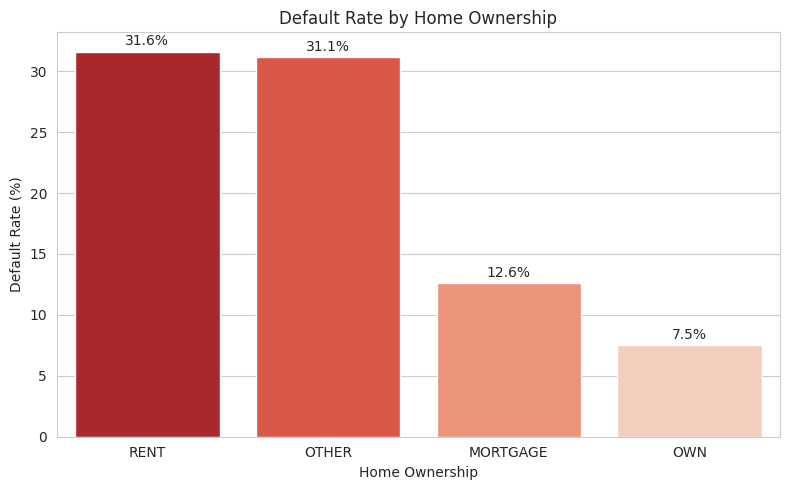

In [17]:
default_rate_home = df.groupby('person_home_ownership')['loan_status'].mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=default_rate_home.index, y=default_rate_home.values, palette='Reds_r')
ax.set_title('Default Rate by Home Ownership')
ax.set_xlabel('Home Ownership')
ax.set_ylabel('Default Rate (%)')

for i, v in enumerate(default_rate_home.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

### 11.5 Default Rate by Loan Grade
Loan grade is meant to score risk, so this rising pattern from A to G is expected — and confirms the grading logic makes sense.

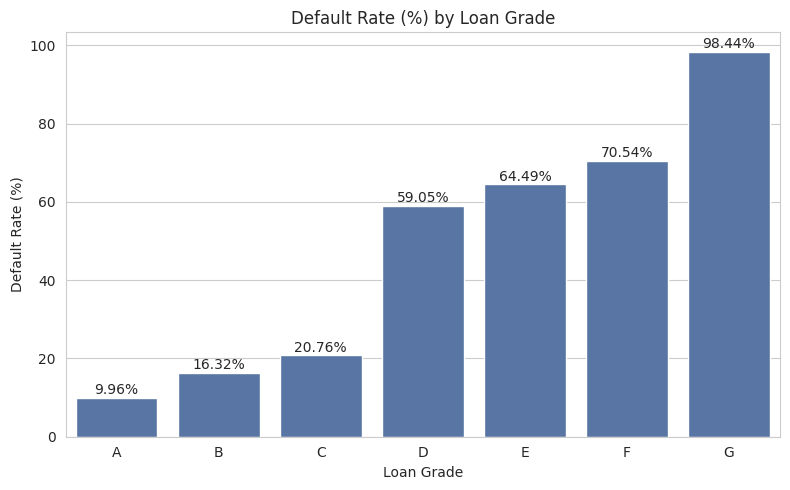

In [18]:
default_rate_grade = df.groupby('loan_grade')['loan_status'].mean().mul(100).sort_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=default_rate_grade.index, y=default_rate_grade.values, color='#4C72B0')
ax.set_title('Default Rate (%) by Loan Grade')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Default Rate (%)')

for i, v in enumerate(default_rate_grade.values):
    ax.text(i, v + 1, f"{v:.2f}%", ha='center')

plt.tight_layout()
plt.show()

### 11.6 Interest Rate by Loan Grade

/tmp/ipykernel_88/2940831836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='loan_grade', y='loan_int_rate', data=df, order=sorted(df['loan_grade'].unique()), palette='coolwarm')


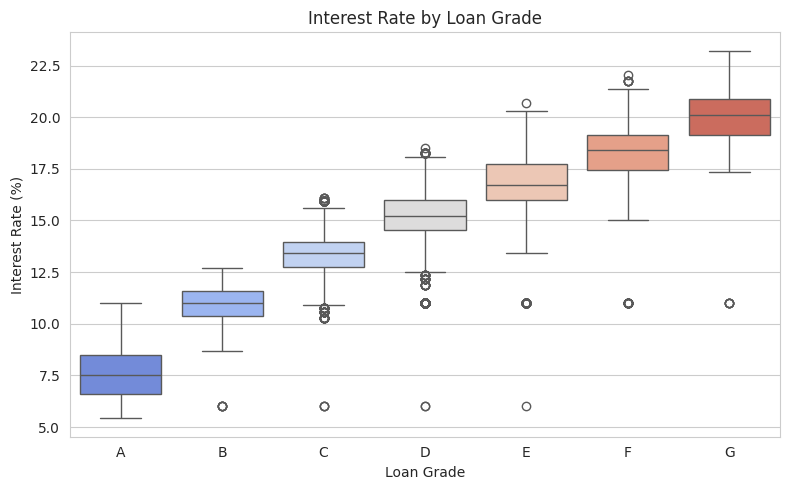

In [19]:
plt.figure(figsize=(8, 5))
ax = sns.boxplot(x='loan_grade', y='loan_int_rate', data=df, order=sorted(df['loan_grade'].unique()), palette='coolwarm')
ax.set_title('Interest Rate by Loan Grade')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Interest Rate (%)')
plt.tight_layout()
plt.show()

### 11.7 Default Rate by Age Group

/tmp/ipykernel_88/4029996195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=default_rate_age.index, y=default_rate_age.values, palette='Purples')


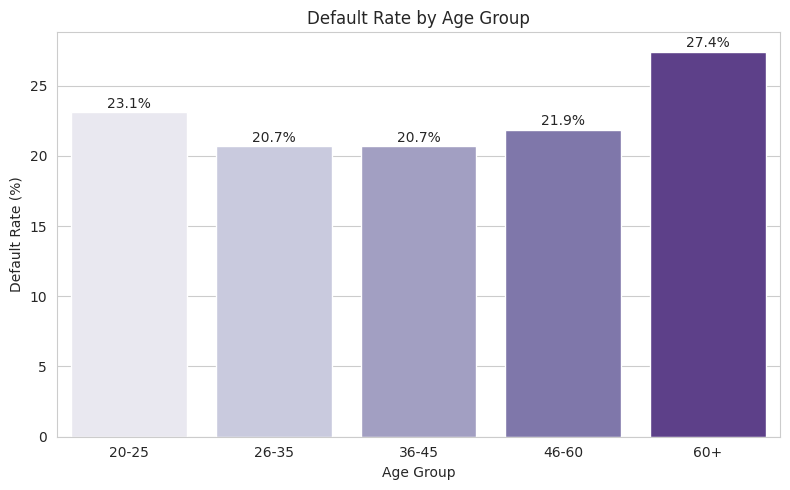

In [20]:
default_rate_age = df.groupby('age_group', observed=True)['loan_status'].mean().mul(100)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=default_rate_age.index, y=default_rate_age.values, palette='Purples')
ax.set_title('Default Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Default Rate (%)')

for i, v in enumerate(default_rate_age.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

### 11.8 Loan Amount as % of Income vs Loan Status
A higher loan-to-income ratio is expected to line up with more defaults.

/tmp/ipykernel_88/52921386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='loan_status', y='loan_percent_income', data=df, palette=['#4C72B0', '#DD8452'])


/tmp/ipykernel_88/52921386.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Default', 'Default'])


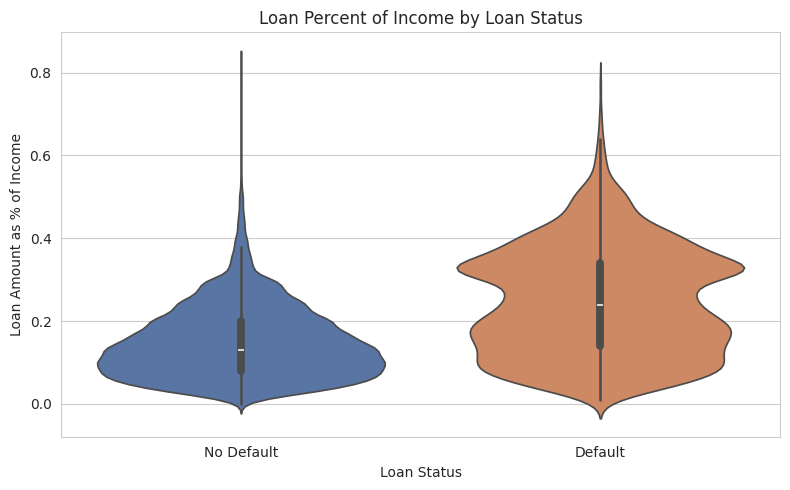

In [21]:
plt.figure(figsize=(8, 5))
ax = sns.violinplot(x='loan_status', y='loan_percent_income', data=df, palette=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['No Default', 'Default'])
ax.set_title('Loan Percent of Income by Loan Status')
ax.set_xlabel('Loan Status')
ax.set_ylabel('Loan Amount as % of Income')
plt.tight_layout()
plt.show()

### 11.9 Correlation Between Numeric Columns

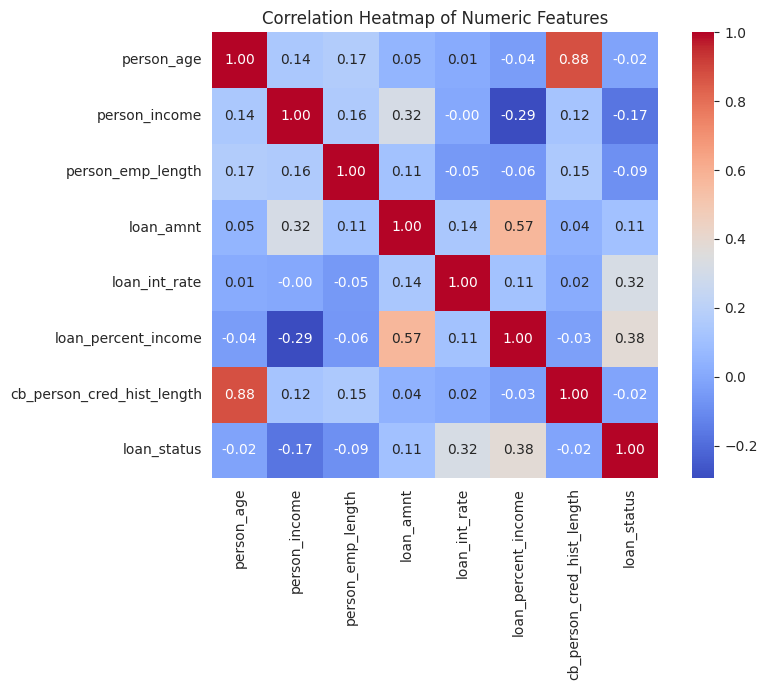

In [22]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

### 11.10 Income vs Loan Amount
Colored by loan status to see if there's a visible pattern.

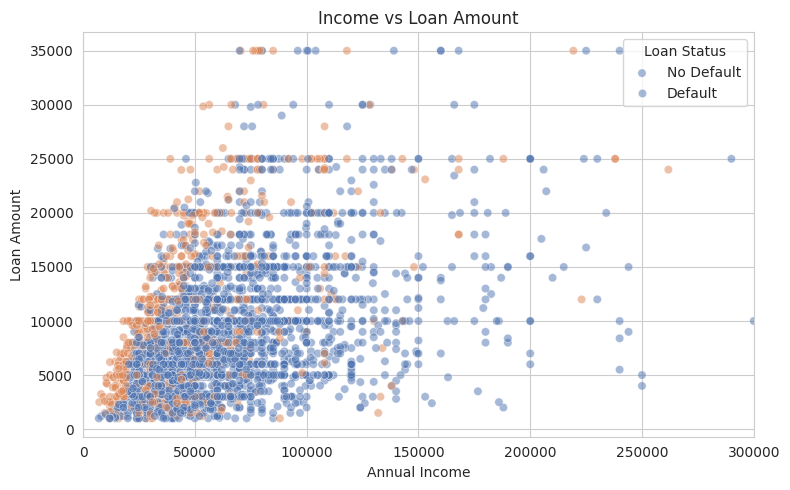

In [23]:
plt.figure(figsize=(8, 5))
sample = df.sample(3000, random_state=42) if len(df) > 3000 else df
sns.scatterplot(x='person_income', y='loan_amnt', hue='loan_status', data=sample,
                palette=['#4C72B0', '#DD8452'], alpha=0.5)
plt.xlim(0, 300000)
plt.title('Income vs Loan Amount')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status', labels=['No Default', 'Default'])
plt.tight_layout()
plt.show()

---
### Summary of what stands out

- The dataset is imbalanced — most applicants do **not** default.
- Loan grade is the strongest and cleanest signal: default rate rises from about 10% at Grade A
  to nearly 98% at Grade G.
- Home ownership status (especially renters) shows a noticeably higher default rate.
- Loan-to-income ratio is another clear signal separating defaulters from non-defaulters.
- Age and credit history length are highly correlated (0.88) — makes sense, since credit
  history naturally grows with age.

## 12. Export Cleaned Data

In [24]:
df.to_csv("cleaned_credit_risk_data.csv", index=False)
print("\nSaved: cleaned_credit_risk_data.csv")


Saved: cleaned_credit_risk_data.csv
